In [1]:
"""
3D Poisson equation solved via Dedalus using RealFourier(x) * RealFourier(y) * Chebyshev(z).
Fourier in x and y decouples each (kx,ky) mode into an independent 1D Chebyshev-in-z
problem, keeping the solve efficient. Only z has Dirichlet BCs (u=0 at z=±Lz/2);
x and y are periodic. The periodicity has negligible effect within r < Lx/2 of the source.

Free-space 3D Green's function: G(r) = -1 / (4*pi*r).
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)

2026-05-11 12:18:38,410 subsystems 0/1 INFO :: Building subproblem matrices 1/256 (~0%) Elapsed: 0s, Remaining: 9s, Rate: 2.8e+01/s
2026-05-11 12:18:38,880 subsystems 0/1 INFO :: Building subproblem matrices 26/256 (~10%) Elapsed: 1s, Remaining: 4s, Rate: 5.1e+01/s
2026-05-11 12:18:39,497 subsystems 0/1 INFO :: Building subproblem matrices 52/256 (~20%) Elapsed: 1s, Remaining: 4s, Rate: 4.6e+01/s
2026-05-11 12:18:39,903 subsystems 0/1 INFO :: Building subproblem matrices 78/256 (~30%) Elapsed: 2s, Remaining: 3s, Rate: 5.1e+01/s
2026-05-11 12:18:40,329 subsystems 0/1 INFO :: Building subproblem matrices 104/256 (~41%) Elapsed: 2s, Remaining: 3s, Rate: 5.3e+01/s
2026-05-11 12:18:40,771 subsystems 0/1 INFO :: Building subproblem matrices 130/256 (~51%) Elapsed: 2s, Remaining: 2s, Rate: 5.4e+01/s
2026-05-11 12:18:41,206 subsystems 0/1 INFO :: Building subproblem matrices 156/256 (~61%) Elapsed: 3s, Remaining: 2s, Rate: 5.5e+01/s
2026-05-11 12:18:41,620 subsystems 0/1 INFO :: Building subpr

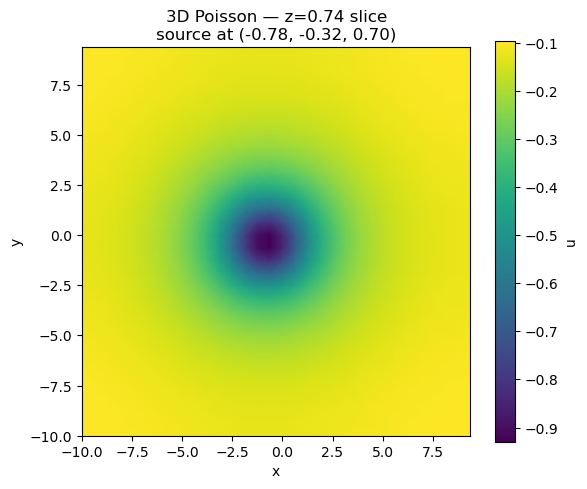

In [4]:
# Parameters
Lx, Ly, Lz = 20, 20, 20
Nx, Ny, Nz = 32, 32, 64
x_left,  x_right = -Lx/2, Lx/2
y_bottom, y_top  = -Ly/2, Ly/2
z_back,  z_front = -Lz/2, Lz/2
dtype = np.float64

# Bases — RealFourier(x) × RealFourier(y) × Chebyshev(z)
coords = d3.CartesianCoordinates('x', 'y', 'z')
dist   = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(x_left,  x_right))
ybasis = d3.RealFourier(coords['y'], size=Ny, bounds=(y_bottom, y_top))
zbasis = d3.Chebyshev( coords['z'], size=Nz, bounds=(z_back,   z_front))

# Fields — only z needs tau terms
u      = dist.Field(name='u',      bases=(xbasis, ybasis, zbasis))
tau_z1 = dist.Field(name='tau_z1', bases=(xbasis, ybasis))
tau_z2 = dist.Field(name='tau_z2', bases=(xbasis, ybasis))

# Forcing — Gaussian source at random location within sphere of radius 2
x, y, z = dist.local_grids(xbasis, ybasis, zbasis)
f = dist.Field(bases=(xbasis, ybasis, zbasis))
r_source = 1.0

rng   = np.random.default_rng()
r_pos = 2 * rng.uniform(0, 1)**(1/3)
cos_t = rng.uniform(-1, 1)
sin_t = np.sqrt(1 - cos_t**2)
phi   = rng.uniform(0, 2*np.pi)
x0 = r_pos * sin_t * np.cos(phi)
y0 = r_pos * sin_t * np.sin(phi)
z0 = r_pos * cos_t

f['g'] = np.exp(-((x - x0)**2 + (y - y0)**2 + (z - z0)**2) / (2*r_source**2))

# Substitutions
lift_basis_z = zbasis.derivative_basis(2)
lift_z = lambda A, n: d3.Lift(A, lift_basis_z, n)

# Problem
problem = d3.LBVP([u, tau_z1, tau_z2], namespace=locals())
problem.add_equation("lap(u) + lift_z(tau_z1,-1) + lift_z(tau_z2,-2) = f")
problem.add_equation("u(z=z_back)  = 0")
problem.add_equation("u(z=z_front) = 0")

# Solver
solver = problem.build_solver()
solver.solve()

# Gather global data
x_g = xbasis.global_grid(dist, scale=1)
y_g = ybasis.global_grid(dist, scale=1)
z_g = zbasis.global_grid(dist, scale=1)
ug  = u.allgather_data('g')  # shape (Nx, Ny, Nz)

# Plot z-slice nearest to source
if dist.comm.rank == 0:
    iz  = np.argmin(np.abs(z_g.ravel() - z0))
    fig, ax = plt.subplots(figsize=(6, 5))
    pcm = ax.pcolormesh(x_g.ravel(), y_g.ravel(), ug[:, :, iz].T,
                        cmap='viridis', shading='gouraud', rasterized=True)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f"3D Poisson — z={z_g.ravel()[iz]:.2f} slice\nsource at ({x0:.2f}, {y0:.2f}, {z0:.2f})")
    plt.colorbar(pcm, ax=ax, label='u')
    plt.tight_layout()
    plt.savefig('poisson_3d.png', dpi=200)
    plt.show()

In [5]:
# Dataset generation — self-contained, independent of visualization cell.
# RealFourier(x) × RealFourier(y) × Chebyshev(z); only z has Dirichlet BCs.

import numpy as np
import dedalus.public as d3

# --- Domain ---
Lx, Ly, Lz = 20, 20, 20
Nx, Ny, Nz = 64, 64, 64
x_left,  x_right = -Lx/2, Lx/2
y_bottom, y_top  = -Ly/2, Ly/2
z_back,  z_front = -Lz/2, Lz/2
dtype = np.float64

coords_ds = d3.CartesianCoordinates('x', 'y', 'z')
dist_ds   = d3.Distributor(coords_ds, dtype=dtype)
xbasis_ds = d3.RealFourier(coords_ds['x'], size=Nx, bounds=(x_left,  x_right))
ybasis_ds = d3.RealFourier(coords_ds['y'], size=Ny, bounds=(y_bottom, y_top))
zbasis_ds = d3.Chebyshev( coords_ds['z'], size=Nz, bounds=(z_back,   z_front))

# --- Fields — only z needs tau terms ---
u_ds      = dist_ds.Field(name='u',      bases=(xbasis_ds, ybasis_ds, zbasis_ds))
tau_z1_ds = dist_ds.Field(name='tau_z1', bases=(xbasis_ds, ybasis_ds))
tau_z2_ds = dist_ds.Field(name='tau_z2', bases=(xbasis_ds, ybasis_ds))
f_ds      = dist_ds.Field(bases=(xbasis_ds, ybasis_ds, zbasis_ds))

lbz = zbasis_ds.derivative_basis(2)
lz  = lambda A, n: d3.Lift(A, lbz, n)

prob_ds = d3.LBVP(
    [u_ds, tau_z1_ds, tau_z2_ds],
    namespace={
        'u': u_ds, 'tau_z1': tau_z1_ds, 'tau_z2': tau_z2_ds,
        'f': f_ds, 'lift_z': lz, 'lap': d3.lap,
        'z_back': z_back, 'z_front': z_front,
    }
)
prob_ds.add_equation("lap(u) + lift_z(tau_z1,-1) + lift_z(tau_z2,-2) = f")
prob_ds.add_equation("u(z=z_back)  = 0")
prob_ds.add_equation("u(z=z_front) = 0")
solver_ds = prob_ds.build_solver()

x_grid_ds = xbasis_ds.global_grid(dist_ds, scale=1)
y_grid_ds = ybasis_ds.global_grid(dist_ds, scale=1)
z_grid_ds = zbasis_ds.global_grid(dist_ds, scale=1)
x_local_ds, y_local_ds, z_local_ds = dist_ds.local_grids(xbasis_ds, ybasis_ds, zbasis_ds)

# --- Sampling parameters ---
r_source_ds = 0.3
r_min = 3 * r_source_ds
r_max = 5.0
N_train = 50

def generate_dataset(n_samples, seed):
    rng = np.random.default_rng(seed=seed)
    X_list, y_list = [], []
    for _ in range(n_samples):
        r_pos = 2 * rng.uniform(0, 1)**(1/3)
        cos_t = rng.uniform(-1, 1)
        sin_t = np.sqrt(1 - cos_t**2)
        phi   = rng.uniform(0, 2 * np.pi)
        x0_i  = r_pos * sin_t * np.cos(phi)
        y0_i  = r_pos * sin_t * np.sin(phi)
        z0_i  = r_pos * cos_t

        f_ds['g'] = np.exp(
            -((x_local_ds - x0_i)**2 + (y_local_ds - y0_i)**2 + (z_local_ds - z0_i)**2)
            / (2 * r_source_ds**2)
        )
        solver_ds.solve()

        ug_i    = u_ds.allgather_data('g')
        r_field = np.sqrt(
            (x_grid_ds - x0_i)**2 + (y_grid_ds - y0_i)**2 + (z_grid_ds - z0_i)**2
        )
        r_flat = r_field.ravel()
        u_flat = ug_i.ravel()
        mask   = (r_flat > r_min) & (r_flat < r_max)
        X_list.append(r_flat[mask])
        y_list.append(u_flat[mask])

    return np.concatenate(X_list), np.concatenate(y_list)

X_train, y_train = generate_dataset(N_train, seed=0)

np.save('greens_function_train_3d.npy', np.stack([X_train, y_train], axis=1))
print(f"Train: {len(X_train)} samples, r in [{X_train.min():.3f}, {X_train.max():.3f}]")

2026-05-11 12:21:10,251 subsystems 0/1 INFO :: Building subproblem matrices 1/1024 (~0%) Elapsed: 0s, Remaining: 44s, Rate: 2.3e+01/s
2026-05-11 12:21:12,326 subsystems 0/1 INFO :: Building subproblem matrices 103/1024 (~10%) Elapsed: 2s, Remaining: 19s, Rate: 4.9e+01/s
2026-05-11 12:21:14,420 subsystems 0/1 INFO :: Building subproblem matrices 206/1024 (~20%) Elapsed: 4s, Remaining: 17s, Rate: 4.9e+01/s
2026-05-11 12:21:16,507 subsystems 0/1 INFO :: Building subproblem matrices 309/1024 (~30%) Elapsed: 6s, Remaining: 15s, Rate: 4.9e+01/s
2026-05-11 12:21:18,481 subsystems 0/1 INFO :: Building subproblem matrices 412/1024 (~40%) Elapsed: 8s, Remaining: 12s, Rate: 5.0e+01/s
2026-05-11 12:21:20,222 subsystems 0/1 INFO :: Building subproblem matrices 496/1024 (~48%) Elapsed: 10s, Remaining: 11s, Rate: 5.0e+01/s
2026-05-11 12:21:20,597 subsystems 0/1 INFO :: Building subproblem matrices 515/1024 (~50%) Elapsed: 10s, Remaining: 10s, Rate: 5.0e+01/s
2026-05-11 12:21:22,563 subsystems 0/1 INF

In [6]:
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [10]:
# Load training dataset
data_train = np.load('greens_function_train_3d.npy')
X_sr = data_train[:, 0].reshape(-1, 1)
y_sr = data_train[:, 1]

# Subsample to keep runtime manageable
rng_sr = np.random.default_rng(seed=1)
idx    = rng_sr.choice(len(X_sr), size=10000, replace=False)
X_sub, y_sub = X_sr[idx], y_sr[idx]

# 3D Green's function is -1/(4*pi*r), so include inv(x)=1/x as a unary operator
model = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*", "^"],
    unary_operators=["log", "cos", "sin", "exp", "inv"],
    delete_tempfiles=True,
    nested_constraints={
        "sin": {"sin": 0, "cos": 0},
        "cos": {"cos": 0, "sin": 0},
        "exp": {"exp": 0, "log": 0},
        "log": {"log": 0, "exp": 0},
        "inv": {"inv": 0},
    },
)
model.fit(X_sub, y_sub)

/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.500e+01
Progress: 1 / 930 total iterations (0.108%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
4           5.823e-03  0.000e+00  y = 0.26178 * sin(0.26178)
8           1.507e-03  3.380e-01  y = inv(((0.23914 + x₀) ^ x₀) * -2.5363)
10          7.399e-05  1.507e+00  y = inv(((0.23914 + x₀) ^ x₀) * -2.5363) * 0.26178
11          7.261e-05  1.892e-02  y = inv(((0.23914 + x₀) ^ x₀) * -2.5363) * sin(0.26178)
13          4.613e-05  2.268e-01  y = inv(((0.23914 + 0.68711) + (x₀ ^ x₀)) * -2.5363) * sin...
                                      (0.26178)
15          1.841e-05  4.594e-01  y = inv((x₀ + ((x₀ + x₀) * x₀)) * -2.5363) * (x₀ * sin(0.2...
                                      6178))
19          2.091e-06  5.437e-01  y = inv(((x₀ * (x₀ + x₀)) + ((x₀ + x₀

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['log', 'cos', ...]"
,expression_spec,None
,niterations,30
,populations,31
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260511_122719_1yUv3R/hall_of_fame.csv


In [11]:

print(model)

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                       -0.008460178   
	1         1.316736e+00                             inv(x0) * -0.029794373   
	2   >>>>  1.660960e+00                     (x0 ^ -1.1112187) * -0.0332276   
	3         2.984244e-01             (inv(x0) * -0.03384102) + 0.0013620178   
	4         6.689948e-05  ((x0 ^ -0.9995098) * -0.033843488) + 0.0013684051   
	5         1.238821e-04  (inv(x0 + 0.0027242359) * -0.033925343) + 0.00...   
	6         1.959059e-05  ((x0 * 8.588233e-6) + 0.0013094054) + ((x0 ^ -...   
	7         3.182968e-08  (((x0 + inv(x0)) * 8.792187e-6) + ((x0 ^ -1.00...   
	8         2.055347e-04  0.0013606774 + (inv(x0 + (cos(exp((x0 * 0.4277...   
	9         2.340449e-06  0.0013604502 + (inv(((0.42909884 * cos(exp((0....   
	10        1.538011e-04  (inv(x0 + (((x0 * 0.4284112) * cos(exp((x0 * 0...   
	11        1.576712e-06  (inv((exp(